# Modélisation du bonheur mondial — Année 2015

## 1. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             f1_score, confusion_matrix, classification_report,
                             silhouette_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch

PALETTE = ['#6B2737', '#C44536', '#E8856E']  # bordeaux → rouge → saumon
ACCENT  = '#457B9D'   # bleu acier (inverse du vert/chaud de 2018)
BG      = '#FAF5F5'   # fond crème rosé très léger

sns.set_theme(style='whitegrid', font_scale=1.05,
              rc={'figure.facecolor': BG, 'axes.facecolor': BG,
                  'axes.edgecolor': '#CCCCCC', 'grid.color': '#E8E8E8',
                  'font.family': 'sans-serif'})

In [2]:
df = pd.read_csv("dataset_2015.csv")
print(f"Dataset chargé : {df.shape[0]} pays, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 157 pays, 14 colonnes


,Year,Country,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,GDP_per_capita,HDI,GII,Freedom_Score,PM25,Suicide_Rate
0,2015,Afghanistan,3.360,1.0,60.515348,8.2600,0.00,-286314.0,565.569730,0.496,0.683,24.0,73.490818,3.46
1,2015,Albania,4.655,0.0,93.394328,56.9000,1.26,-20500.0,4199.539129,0.797,0.179,67.0,19.121557,4.13
2,2015,Algeria,6.355,1.0,91.420151,38.2000,0.04,-27638.0,4685.059027,0.737,0.397,34.0,25.618866,2.17
3,2015,Angola,3.866,0.0,58.619631,22.0000,0.13,74171.0,3641.728939,0.603,0.549,28.0,25.002150,6.56
4,2015,Argentina,6.650,0.0,98.982308,68.0431,0.18,5464.0,13679.626498,0.859,0.338,80.0,14.624551,8.77


## 2. Exploration et prétraitement

In [3]:
cols_all = ["Life_evaluation", "Conflit", "Water_Access",
            "population using the Internet", "Coastline", "Net_Migration",
            "GDP_per_capita", "HDI", "GII", "Freedom_Score", "PM25", "Suicide_Rate"]

df[cols_all].describe().round(2)

,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,GDP_per_capita,HDI,GII,Freedom_Score,PM25,Suicide_Rate
count,157.00,153.00,150.00,151.00,153.00,154.00,154.00,151.00,142.00,157.00,152.00,152.00
mean,5.38,0.28,87.32,48.13,2.62,380.26,13923.64,0.73,0.35,59.45,29.75,9.04
std,1.14,0.45,16.49,29.12,8.24,312026.88,19134.55,0.16,0.20,28.61,20.67,6.27
min,2.90,0.00,36.31,1.76,0.00,-2172162.00,254.40,0.32,0.03,-1.00,5.63,0.61
25%,4.40,0.00,80.97,19.34,0.00,-27603.75,1618.69,0.60,0.17,34.00,17.12,4.77
50%,5.31,0.00,94.77,50.30,0.24,-3427.00,5594.68,0.76,0.38,62.00,23.66,7.12
75%,6.27,1.00,99.22,72.28,1.42,15876.75,17573.09,0.86,0.53,85.00,34.38,12.02
max,7.53,1.00,100.00,98.20,67.12,1722127.00,105462.01,0.96,0.82,100.00,107.14,34.49


### 2.1 Distribution des variables

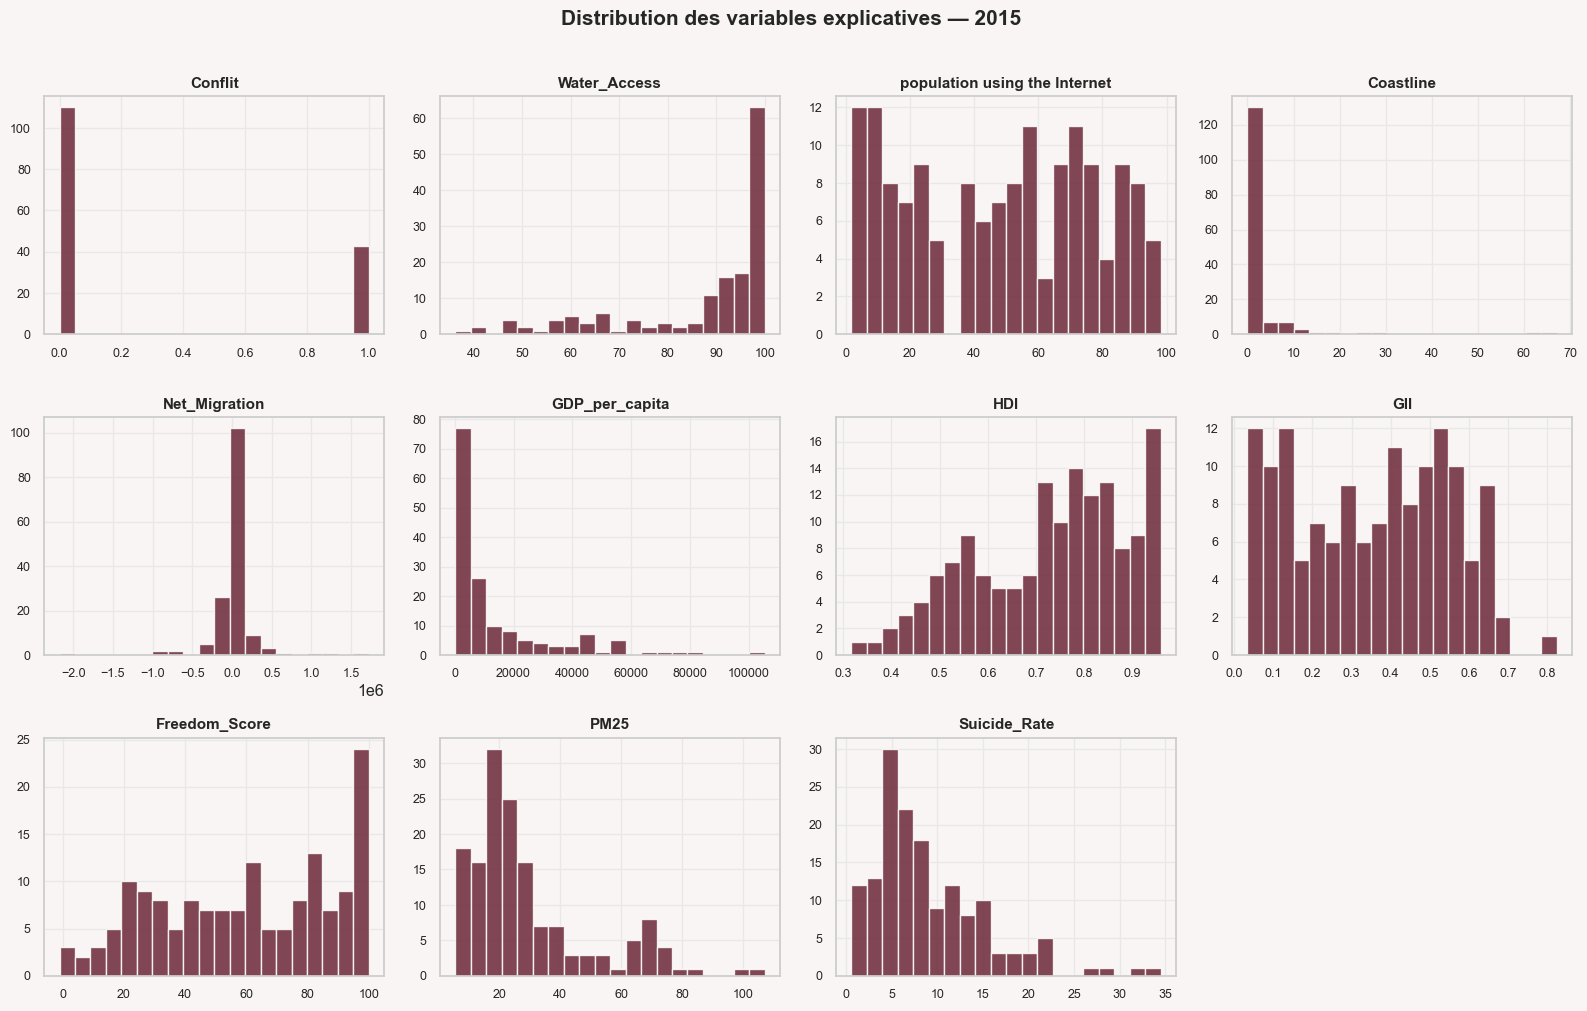

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
features = [c for c in cols_all if c != "Life_evaluation"]

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution des variables explicatives — 2015", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Transformations log

In [5]:
df['GDP_per_capita'] = np.log(df['GDP_per_capita'])
df['PM25'] = np.log(df['PM25'])

### 2.3 Recodage de Coastline

In [6]:
coastline_median = df.loc[df['Coastline'] > 0, 'Coastline'].median()
print(f"Médiane des pays côtiers : {coastline_median:.2f}")

def recode_coastline(val):
    if val == 0:
        return 0
    elif val <= coastline_median:
        return 1
    else:
        return 2

df['Coastline'] = df['Coastline'].apply(recode_coastline).astype(float)

analyse_mer = df.groupby('Coastline')['Life_evaluation'].mean()
print("\nMoyenne de bonheur par catégorie de Coastline :")
print(analyse_mer.round(3))

Médiane des pays côtiers : 0.54

Moyenne de bonheur par catégorie de Coastline :
Coastline
0.0    4.972
1.0    5.075
2.0    5.931
Name: Life_evaluation, dtype: float64


### 2.4 Valeurs manquantes

In [7]:
print("Nombre total de pays :", len(df))
print("NaN dans Life_evaluation :", df['Life_evaluation'].isna().sum())
print("Pays exploitables :", df['Life_evaluation'].notna().sum())

Nombre total de pays : 157
NaN dans Life_evaluation : 0
Pays exploitables : 157


### 2.5 Matrice de corrélation

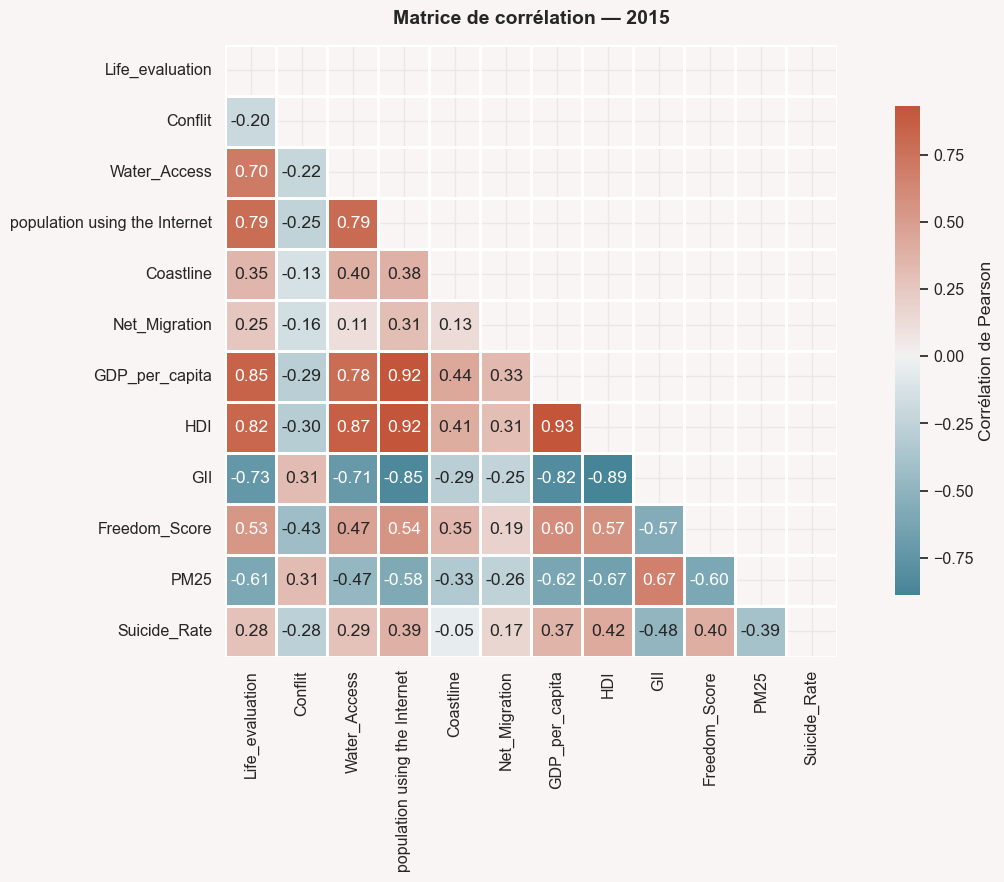

In [8]:
corr_matrix = df[cols_all].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, linewidths=0.8, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})
ax.set_title("Matrice de corrélation — 2015", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 3. Régression

### 3.1 Régression linéaire — PIB

In [9]:
cols_gdp = ["Conflit", "Coastline", "Net_Migration", "GDP_per_capita",
            "Freedom_Score", "PM25", "Suicide_Rate"]
target = "Life_evaluation"

X = df[cols_gdp]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr_gdp = LinearRegression()
scores_cv = cross_val_score(model_lr_gdp, X_train_scaled, y_train, cv=5, scoring='r2')
model_lr_gdp.fit(X_train_scaled, y_train)
y_pred = model_lr_gdp.predict(X_test_scaled)

print(f"R² Train              : {model_lr_gdp.score(X_train_scaled, y_train):.3f}")
print(f"R² Cross-val (5-fold) : {scores_cv.mean():.3f}")
print(f"R² Test               : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test              : {mean_squared_error(y_test, y_pred):.3f}")

R² Train              : 0.751
R² Cross-val (5-fold) : 0.705
R² Test               : 0.669
MSE Test              : 0.440


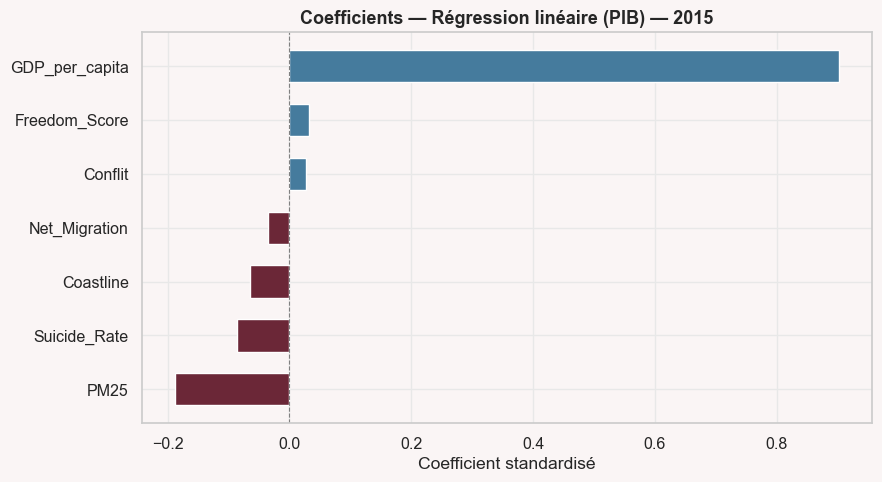

In [10]:
coef_df = pd.DataFrame({"Variable": cols_gdp, "Coefficient": model_lr_gdp.coef_}).sort_values(by="Coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if c > 0 else PALETTE[0] for c in coef_df["Coefficient"]]
ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title("Coefficients — Régression linéaire (PIB) — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient standardisé")
plt.tight_layout()
plt.show()

### 3.2 Régression linéaire — Internet

In [11]:
cols_internet = ["Conflit", "Coastline", "Net_Migration",
                 "population using the Internet", "Freedom_Score", "PM25", "Suicide_Rate"]

X = df[cols_internet]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr_int = LinearRegression()
scores_cv = cross_val_score(model_lr_int, X_train_scaled, y_train, cv=5, scoring='r2')
model_lr_int.fit(X_train_scaled, y_train)
y_pred = model_lr_int.predict(X_test_scaled)

print(f"R² Train              : {model_lr_int.score(X_train_scaled, y_train):.3f}")
print(f"R² Cross-val (5-fold) : {scores_cv.mean():.3f}")
print(f"R² Test               : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test              : {mean_squared_error(y_test, y_pred):.3f}")

R² Train              : 0.647
R² Cross-val (5-fold) : 0.576
R² Test               : 0.651
MSE Test              : 0.465


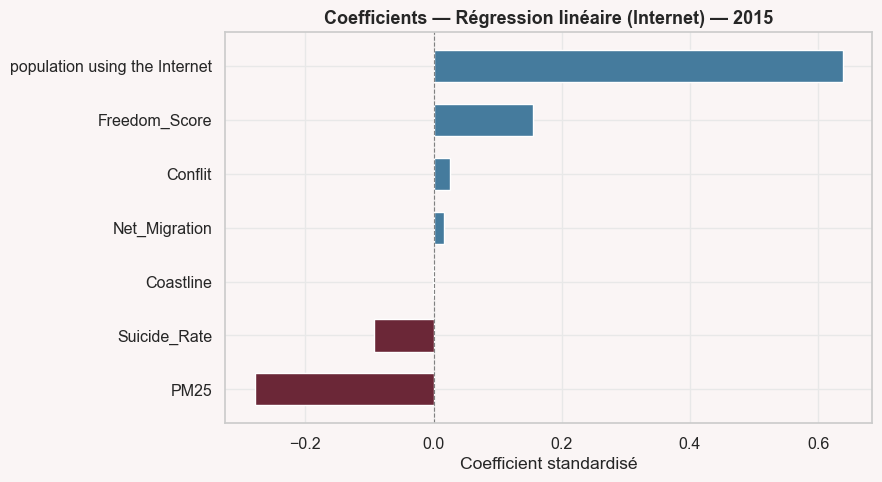

In [12]:
coef_df = pd.DataFrame({"Variable": cols_internet, "Coefficient": model_lr_int.coef_}).sort_values(by="Coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if c > 0 else PALETTE[0] for c in coef_df["Coefficient"]]
ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title("Coefficients — Régression linéaire (Internet) — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient standardisé")
plt.tight_layout()
plt.show()

---
### 3.3 Random Forest

#### Random Forest — 11 variables

R² Train : 0.838
R² Test  : 0.721
MSE Test : 0.371


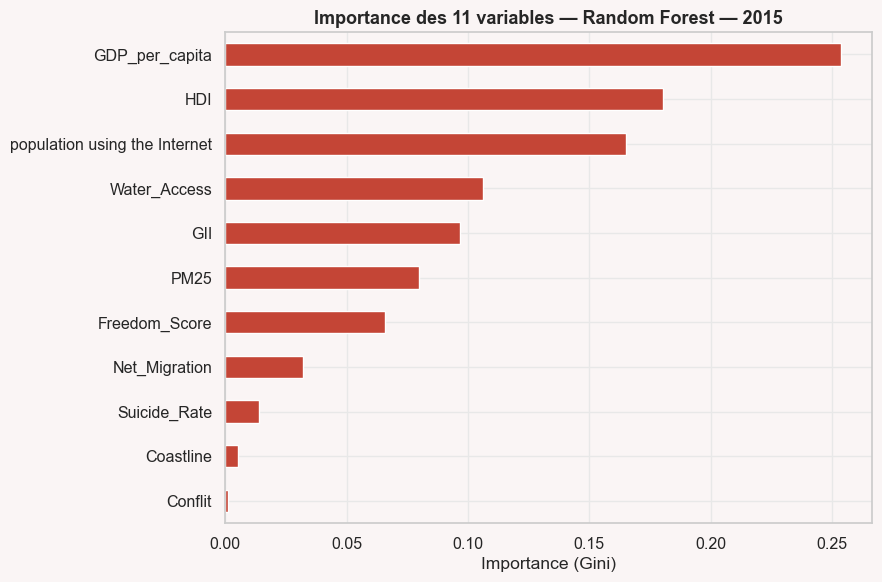

In [13]:
cols_11 = ["Conflit", "Water_Access", "population using the Internet", "Coastline",
           "Net_Migration", "GDP_per_capita", "HDI", "GII", "Freedom_Score", "PM25", "Suicide_Rate"]

X = df[cols_11]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_11 = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                               max_features='sqrt', random_state=42)
rf_11.fit(X_train, y_train)
y_pred = rf_11.predict(X_test)

print(f"R² Train : {rf_11.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")

feat_imp = pd.Series(rf_11.feature_importances_, index=cols_11).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 11 variables — Random Forest — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

#### Random Forest — 7 variables (PIB)

R² Train : 0.793
R² Test  : 0.644
MSE Test : 0.474


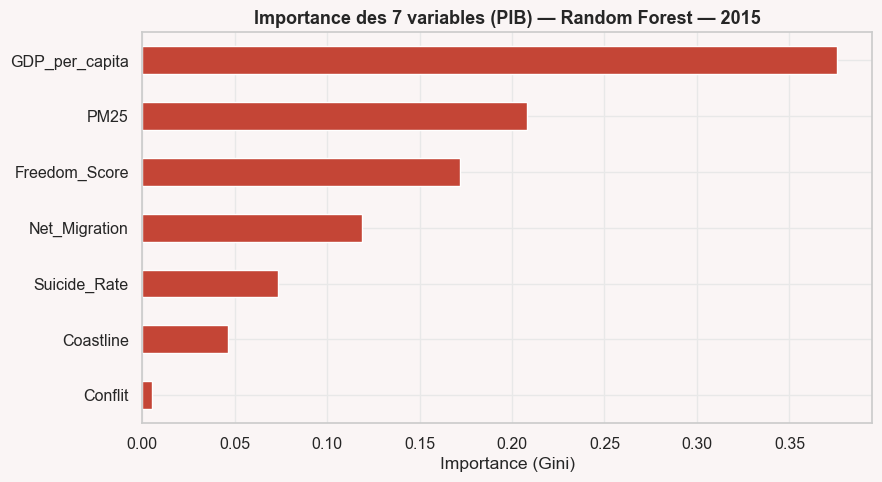

In [14]:
X = df[cols_gdp]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_gdp = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                                max_features='sqrt', random_state=42)
rf_gdp.fit(X_train, y_train)
y_pred = rf_gdp.predict(X_test)

print(f"R² Train : {rf_gdp.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")

feat_imp = pd.Series(rf_gdp.feature_importances_, index=cols_gdp).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 7 variables (PIB) — Random Forest — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

#### Random Forest — 7 variables (Internet)

R² Train : 0.746
R² Test  : 0.644
MSE Test : 0.474


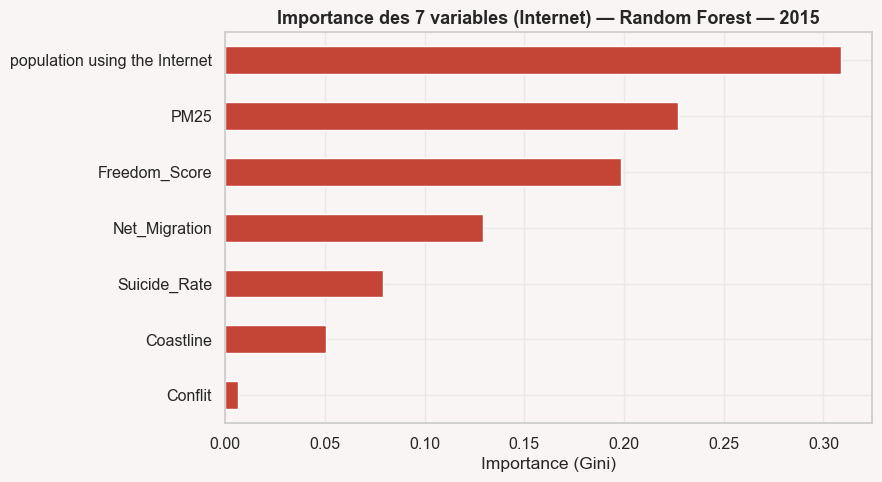

In [15]:
X = df[cols_internet]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_int = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                                max_features='sqrt', random_state=42)
rf_int.fit(X_train, y_train)
y_pred = rf_int.predict(X_test)

print(f"R² Train : {rf_int.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")

feat_imp = pd.Series(rf_int.feature_importances_, index=cols_internet).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 7 variables (Internet) — Random Forest — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

---
### 3.4 Gradient Boosting

#### Gradient Boosting — 11 variables

R² Train : 0.794
R² Test  : 0.671


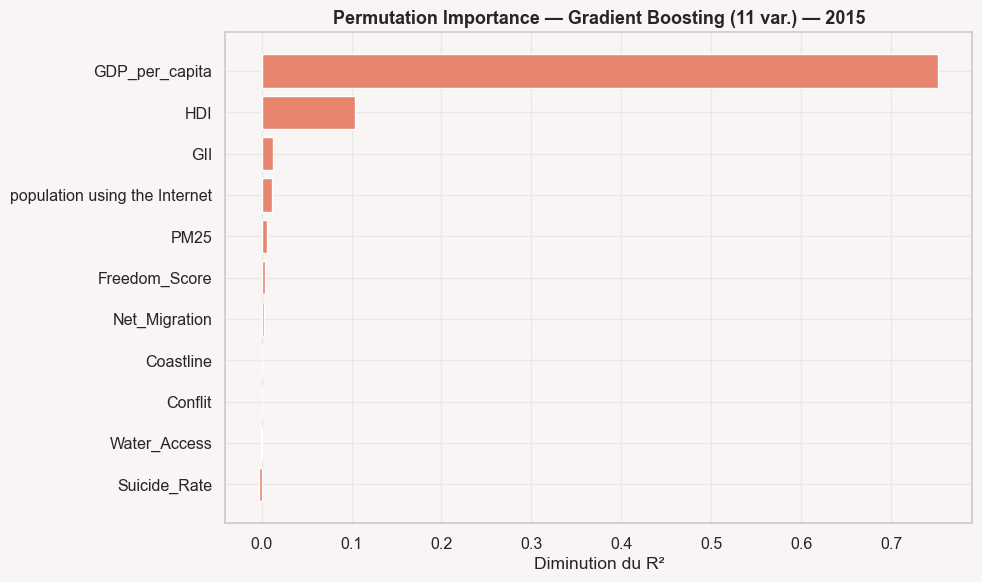

In [16]:
X = df[cols_11]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_11 = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.01, max_depth=3,
                                       l2_regularization=0.1, random_state=42)
gb_11.fit(X_train, y_train)
y_pred_gb = gb_11.predict(X_test)

print(f"R² Train : {gb_11.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")

result = permutation_importance(gb_11, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_11[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (11 var.) — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R²")
plt.tight_layout()
plt.show()

#### Gradient Boosting — 7 variables (PIB)

R² Train : 0.883
R² Test  : 0.617


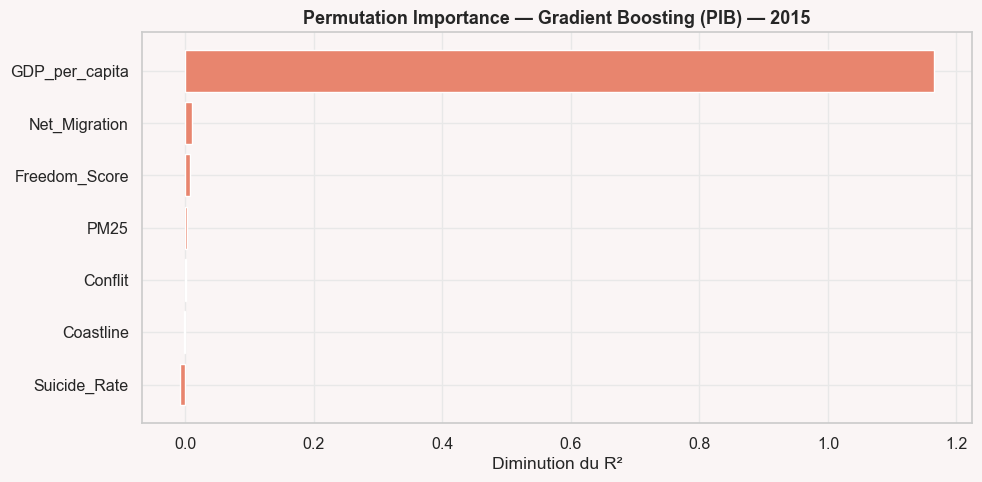

In [17]:
X = df[cols_gdp]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_gdp = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=3,
                                        l2_regularization=0.1, random_state=42)
gb_gdp.fit(X_train, y_train)
y_pred_gb = gb_gdp.predict(X_test)

print(f"R² Train : {gb_gdp.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")

result = permutation_importance(gb_gdp, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_gdp[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (PIB) — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R²")
plt.tight_layout()
plt.show()

#### Gradient Boosting — 7 variables (Internet)

R² Train : 0.851
R² Test  : 0.625


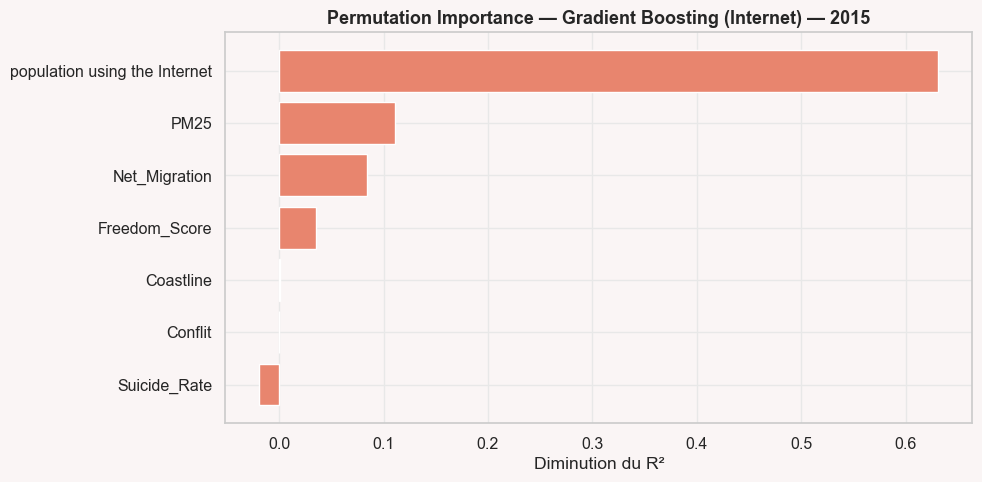

In [18]:
X = df[cols_internet]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_int = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=3,
                                        l2_regularization=0.1, random_state=42)
gb_int.fit(X_train, y_train)
y_pred_gb = gb_int.predict(X_test)

print(f"R² Train : {gb_int.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")

result = permutation_importance(gb_int, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_internet[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (Internet) — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R²")
plt.tight_layout()
plt.show()

---
## 4. Classification

### 4.1 Distribution de Life_evaluation

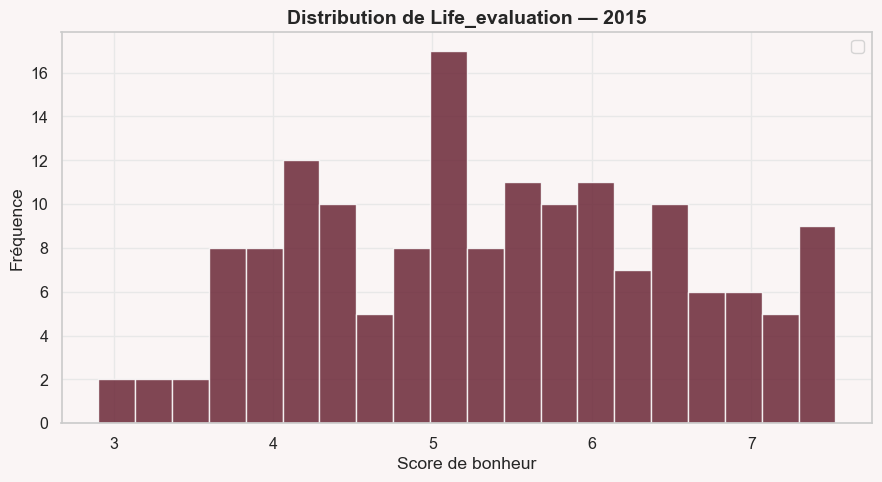

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Life_evaluation"].dropna(), bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.set_title("Distribution de Life_evaluation — 2015", fontsize=14, fontweight='bold')
ax.set_xlabel("Score de bonheur")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Classification avec `qcut`

In [33]:
cols_clf = ["Conflit", "Coastline", "Net_Migration", "GDP_per_capita",
            "Freedom_Score", "PM25", "Suicide_Rate"]

df['Classe_Bonheur'] = pd.qcut(df['Life_evaluation'], q=3, labels=[0, 1, 2])

X = df[cols_clf]
y = df['Classe_Bonheur']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Régression Logistique

Précision Train : 0.744
Précision Test  : 0.656

              precision    recall  f1-score   support

           0       0.75      0.82      0.78        11
           1       0.40      0.50      0.44         8
           2       0.80      0.62      0.70        13

    accuracy                           0.66        32
   macro avg       0.65      0.64      0.64        32
weighted avg       0.68      0.66      0.66        32



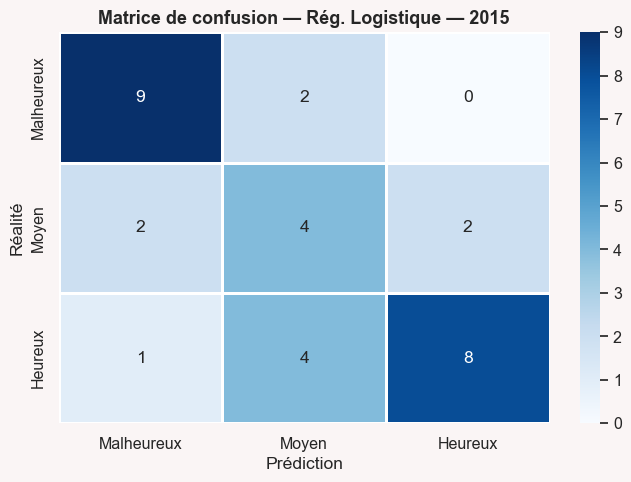

In [34]:
model_log = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model_log.fit(X_train_scaled, y_train)
y_pred = model_log.predict(X_test_scaled)

print(f"Précision Train : {model_log.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_log.score(X_test_scaled, y_test):.3f}")
print()
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — Rég. Logistique — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

#### KNN

Précision Train : 0.704
Précision Test  : 0.625

              precision    recall  f1-score   support

           0       0.70      0.64      0.67        11
           1       0.42      0.62      0.50         8
           2       0.80      0.62      0.70        13

    accuracy                           0.62        32
   macro avg       0.64      0.63      0.62        32
weighted avg       0.67      0.62      0.64        32



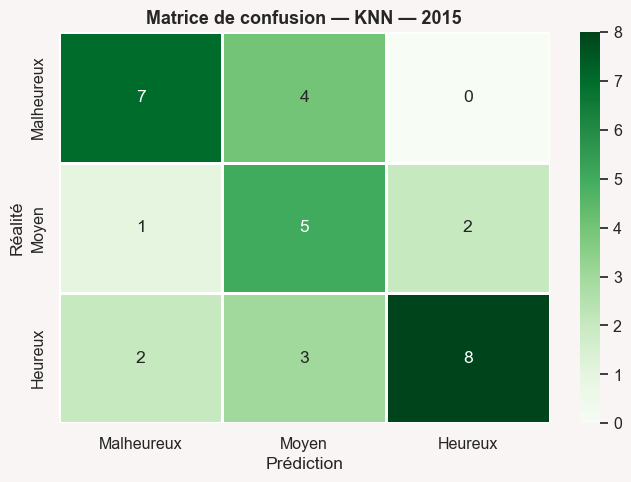

In [35]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

print(f"Précision Train : {model_knn.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_knn.score(X_test_scaled, y_test):.3f}")
print()
print(classification_report(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — KNN — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

#### Naive Bayes

Précision Train : 0.672
Précision Test  : 0.594

              precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.25      0.25      0.25         8
           2       0.69      0.69      0.69        13

    accuracy                           0.59        32
   macro avg       0.56      0.56      0.56        32
weighted avg       0.59      0.59      0.59        32



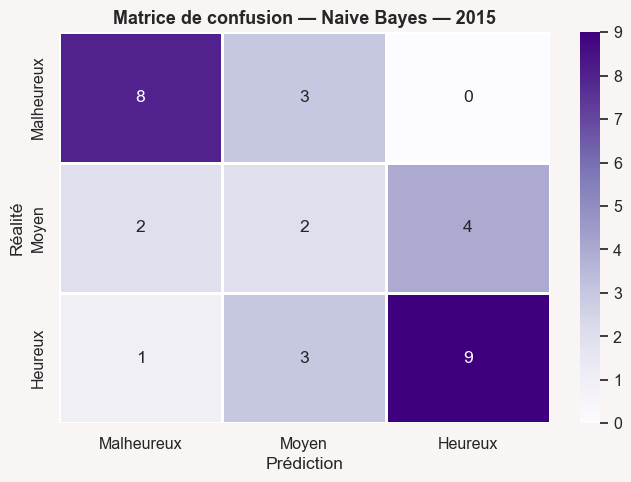

In [36]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)
y_pred_nb = model_nb.predict(X_test_scaled)

print(f"Précision Train : {model_nb.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_nb.score(X_test_scaled, y_test):.3f}")
print()
print(classification_report(y_test, y_pred_nb))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — Naive Bayes — 2015", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

---
## 5. K-Means

### 5.1 Choix du nombre de clusters

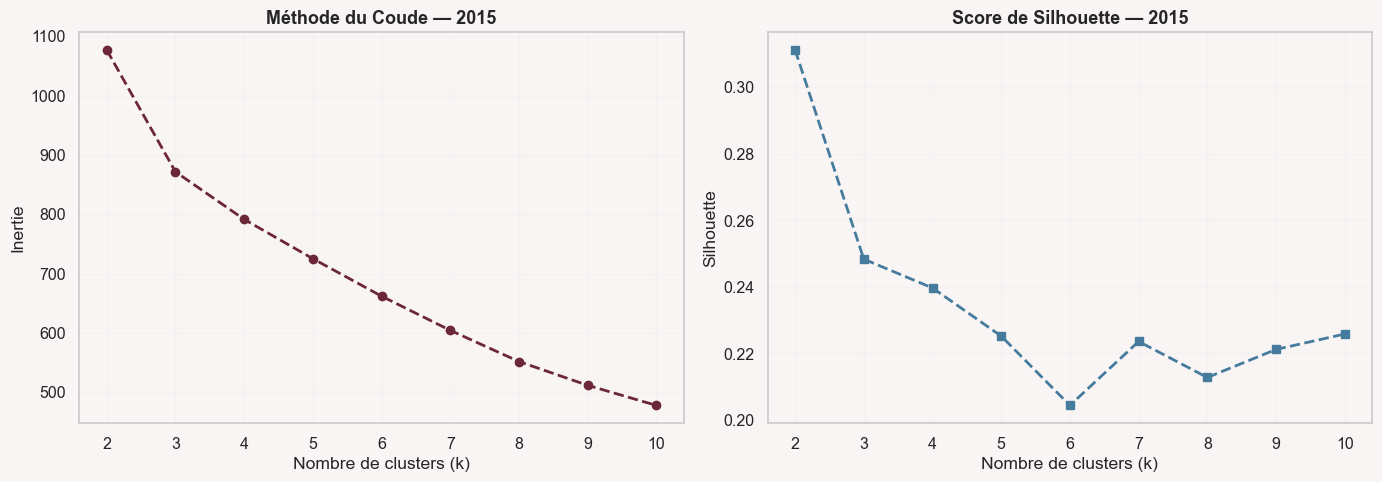

In [37]:
cols_clust = ["Conflit", "Water_Access", "population using the Internet", "Coastline",
              "Net_Migration", "Freedom_Score", "PM25", "Suicide_Rate",
              "GDP_per_capita", "HDI", "GII"]

df_clustering = df[['Country', 'Life_evaluation'] + cols_clust].copy()
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(df_clustering[cols_clust])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', linestyle='--', color=PALETTE[0], linewidth=2)
ax1.set_title("Méthode du Coude — 2015", fontsize=13, fontweight='bold')
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Inertie")
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, marker='s', linestyle='--', color=ACCENT, linewidth=2)
ax2.set_title("Score de Silhouette — 2015", fontsize=13, fontweight='bold')
ax2.set_xlabel("Nombre de clusters (k)")
ax2.set_ylabel("Silhouette")
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Dendrogramme

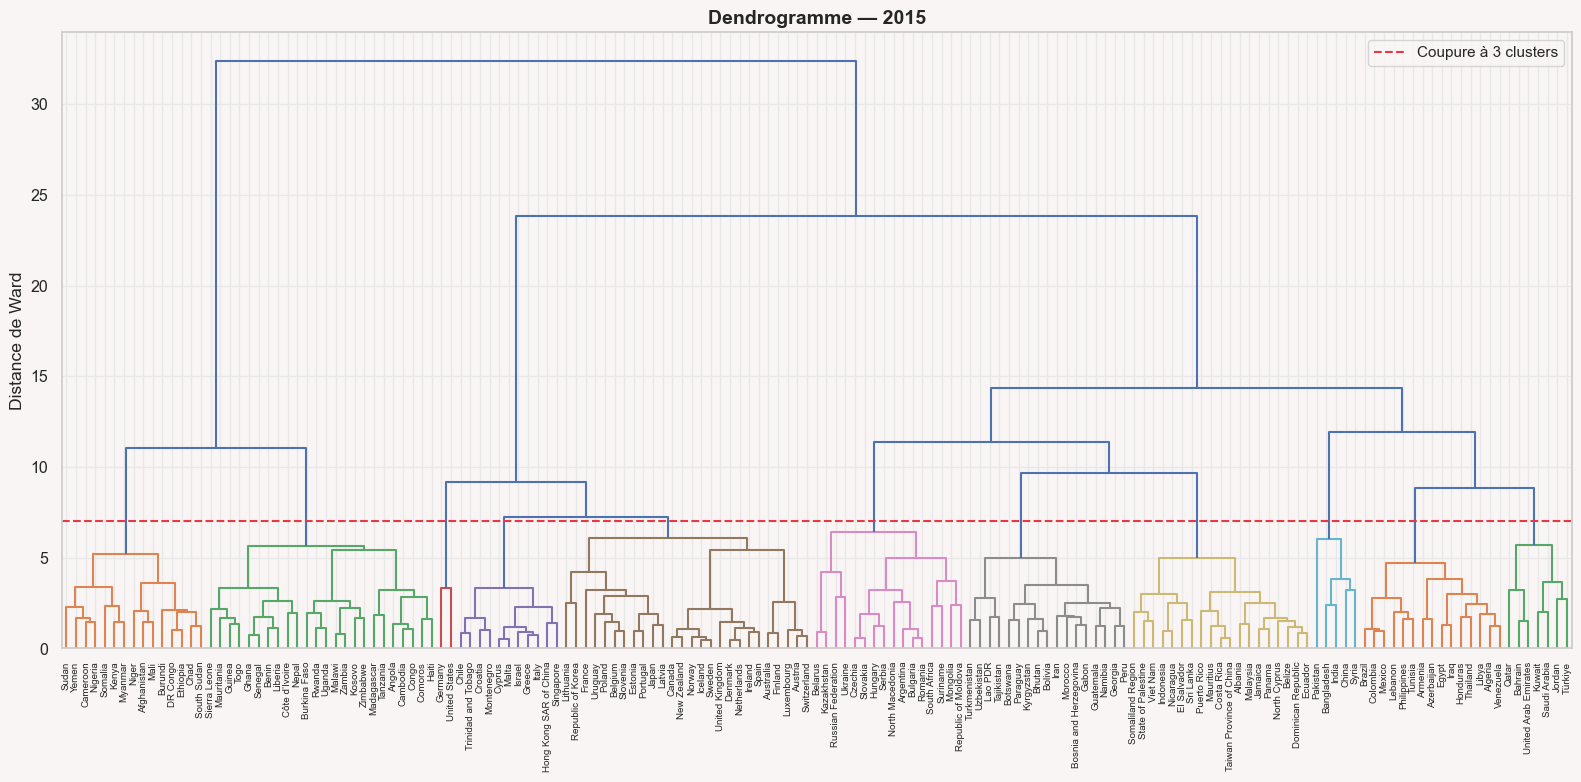

In [38]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(Z, labels=df_clustering['Country'].values,
                    leaf_rotation=90., leaf_font_size=7., color_threshold=7, ax=ax)
ax.axhline(y=7, color='#E63946', linestyle='--', linewidth=1.5, label='Coupure à 3 clusters')
ax.set_title("Dendrogramme — 2015", fontsize=14, fontweight='bold')
ax.set_ylabel("Distance de Ward")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 5.3 K-Means (k=3) + ACP

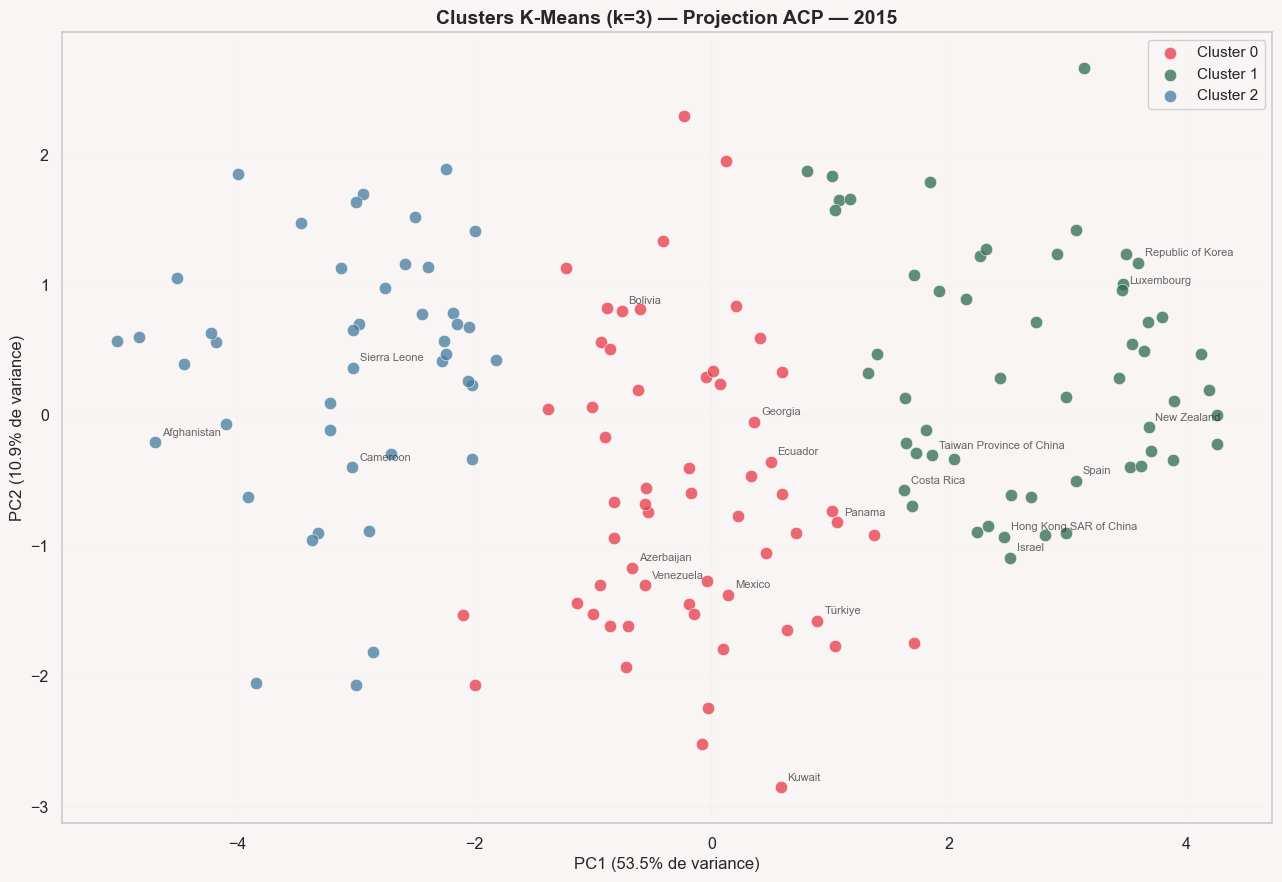

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(X_scaled).astype(int)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clustering['PC1'] = X_pca[:, 0]
df_clustering['PC2'] = X_pca[:, 1]

cluster_colors = {0: '#E63946', 1: '#2D6A4F', 2: '#457B9D'}

fig, ax = plt.subplots(figsize=(13, 9))
for cluster_id, color in cluster_colors.items():
    mask = df_clustering['Cluster'] == cluster_id
    ax.scatter(df_clustering.loc[mask, 'PC1'], df_clustering.loc[mask, 'PC2'],
               c=color, s=80, alpha=0.75, edgecolors='white', linewidth=0.5,
               label=f'Cluster {cluster_id}')

for i in range(0, len(df_clustering), 8):
    row = df_clustering.iloc[i]
    ax.annotate(row['Country'], (row['PC1'], row['PC2']),
                fontsize=8, alpha=0.7, ha='left',
                xytext=(5, 5), textcoords='offset points')

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC1 ({var1:.1f}% de variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var2:.1f}% de variance)", fontsize=12)
ax.set_title("Clusters K-Means (k=3) — Projection ACP — 2015", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 5.4 Profils par cluster

In [40]:
df_clustering['Coastline'] = df_clustering['Coastline'].astype(float)
profils = df_clustering.groupby('Cluster')[['Life_evaluation'] + cols_clust].mean().round(2)
profils

,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,Freedom_Score,PM25,Suicide_Rate,GDP_per_capita,HDI,GII
Cluster,,,,,,,,,,,,
0,5.44,0.38,93.25,47.88,1.24,3886.14,49.24,3.29,6.23,8.59,0.74,0.39
1,6.32,0.06,98.89,75.89,1.42,106443.30,86.02,2.60,14.36,10.06,0.88,0.16
2,4.14,0.43,64.83,12.77,0.66,-134250.05,39.70,3.75,6.14,6.96,0.52,0.57


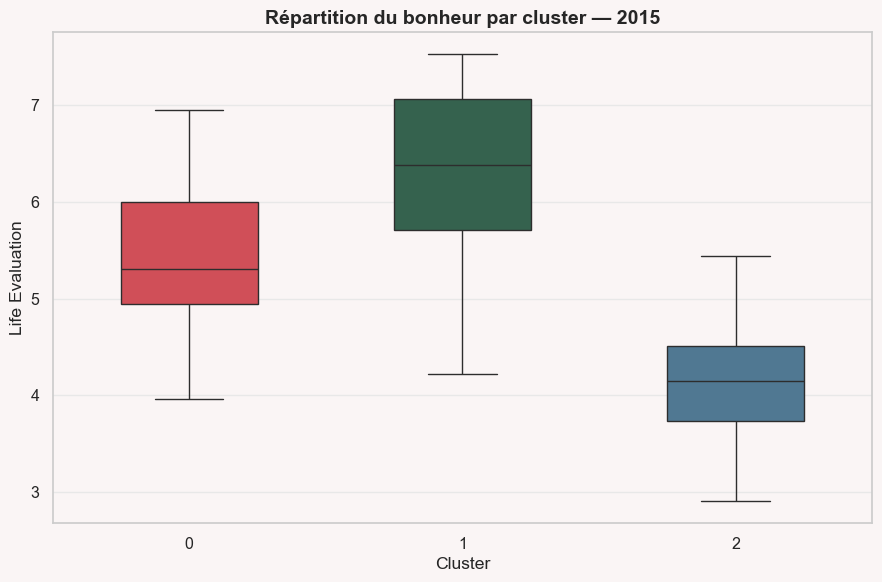

In [41]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(x='Cluster', y='Life_evaluation', data=df_clustering,
            palette=['#E63946', '#2D6A4F', '#457B9D'], width=0.5, ax=ax)
ax.set_title("Répartition du bonheur par cluster — 2015", fontsize=14, fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Life Evaluation")
plt.tight_layout()
plt.show()

### 5.5 Cas d'étude

In [42]:
comparaison = df_clustering[df_clustering['Country'].isin(['Costa Rica', 'Nicaragua', 'Republic of Korea'])]
cols_comp = ['Country', 'Cluster', 'Life_evaluation', 'GDP_per_capita', 'Freedom_Score',
             'GII', 'HDI', 'Suicide_Rate', 'PM25', 'Net_Migration', 'Coastline']
comparaison[cols_comp]

,Country,Cluster,Life_evaluation,GDP_per_capita,Freedom_Score,GII,HDI,Suicide_Rate,PM25,Net_Migration,Coastline
32,Costa Rica,1,7.087,9.368601,90.0,0.282,0.803,6.37,2.871507,1617.0,2.0
97,Nicaragua,0,5.992,7.637454,54.0,0.431,0.679,4.72,3.035436,-24353.0,2.0
112,Republic of Korea,1,5.835,10.314663,84.0,0.067,0.914,28.23,3.269187,276427.0,2.0


### 5.6 Validation par rang de bonheur

In [43]:
for c in range(kmeans.n_clusters):
    pays = df_clustering[df_clustering['Cluster'] == c]['Country'].values
    print(f"\nCluster {c} ({len(pays)} pays) : {', '.join(pays[:10])}{'...' if len(pays) > 10 else ''}")


Cluster 0 (58 pays) : Albania, Algeria, Armenia, Azerbaijan, Bahrain, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana...

Cluster 1 (55 pays) : Argentina, Australia, Austria, Belarus, Belgium, Bulgaria, Canada, Chile, Costa Rica, Croatia...

Cluster 2 (44 pays) : Afghanistan, Angola, Bangladesh, Benin, Burkina Faso, Burundi, Cambodia, Cameroon, Chad, Congo...


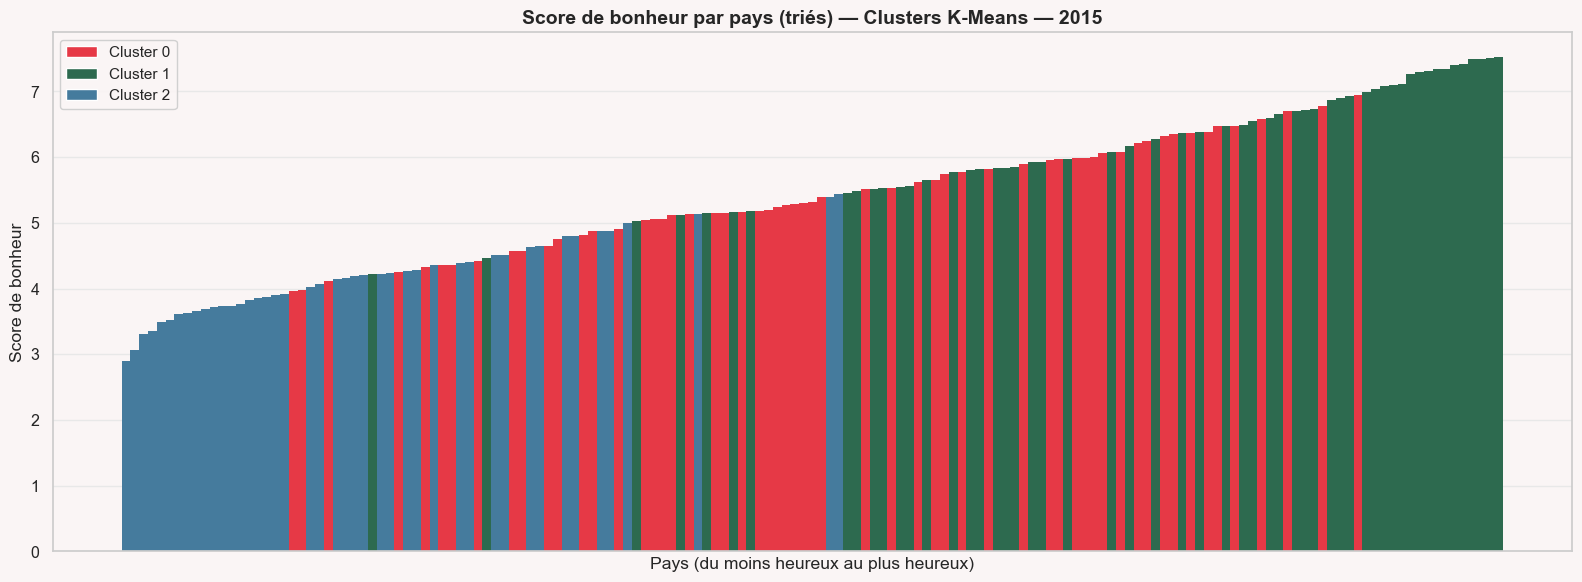

In [44]:
df_ranked = df_clustering.sort_values(by='Life_evaluation').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
for idx, row in df_ranked.iterrows():
    ax.bar(idx, row['Life_evaluation'], color=cluster_colors[row['Cluster']],
           edgecolor='none', width=1.0)

legend_elements = [Patch(facecolor=cluster_colors[i], label=f'Cluster {i}') for i in range(3)]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', framealpha=0.9)

ax.set_title("Score de bonheur par pays (triés) — Clusters K-Means — 2015",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Pays (du moins heureux au plus heureux)")
ax.set_ylabel("Score de bonheur")
ax.set_xticks([])
plt.tight_layout()
plt.show()